In [ ]:
# ============================================================
# EDA FOR applications.csv  (Steam Game Metadata)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

apps = pd.read_csv("/content/applications.csv", engine="python", on_bad_lines="skip")
apps_raw = apps.copy()

print("Shape:", apps.shape)
apps.head()


Shape: (15508, 30)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,metacritic_score,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0.00,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,88.00,161854.00,True,True,True,999.00,999.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0.00,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,6633.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0.00,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,79.00,4308.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0.00,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,2338.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0.00,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,NaN,22793.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


In [ ]:
apps.columns = apps.columns.str.lower()
apps.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15508 entries, 0 to 15507
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appid                  15508 non-null  int64  
 1   name                   15508 non-null  object 
 2   type                   15177 non-null  object 
 3   is_free                15507 non-null  object 
 4   release_date           15124 non-null  object 
 5   required_age           15507 non-null  float64
 6   short_description      14995 non-null  object 
 7   supported_languages    15262 non-null  object 
 8   header_image           15507 non-null  object 
 9   background             15507 non-null  object 
 10  metacritic_score       2771 non-null   float64
 11  recommendations_total  5385 non-null   float64
 12  mat_supports_windows   15507 non-null  object 
 13  mat_supports_mac       15507 non-null  object 
 14  mat_supports_linux     15507 non-null  object 
 15  ma

In [ ]:
missing = apps.isna().sum().sort_values(ascending=False)
missing


,0
metacritic_score,12737
recommendations_total,10123
mat_achievement_count,10037
mat_pc_graphics_rec,9377
mat_pc_processor_rec,8995
mat_pc_os_rec,8986
mat_pc_memory_rec,8778
mat_pc_graphics_min,4082
mat_initial_price,3097
mat_discount_percent,3097


In [ ]:
apps.describe()


,appid,required_age,metacritic_score,recommendations_total,mat_initial_price,mat_final_price,mat_discount_percent,mat_achievement_count
count,15508.00,15507.00,2771.00,5385.00,12411.00,12411.00,12411.00,5471.00
mean,297866.91,1.23,72.34,8803.92,67292.65,51603.26,7.91,36.79
std,123390.80,4.37,10.80,83140.70,1372119.07,957589.30,22.73,100.67
min,10.00,0.00,20.00,101.00,50.00,44.00,0.00,0.00
25%,243135.00,0.00,66.00,208.00,399.00,299.00,0.00,14.00
50%,329185.00,0.00,74.00,514.00,699.00,599.00,0.00,24.00
75%,390388.25,0.00,80.00,2020.00,1299.00,999.00,0.00,41.00
max,452193.00,18.00,96.00,4661011.00,89900000.00,48000000.00,95.00,4996.00


In [ ]:
apps.describe(include="object").transpose()


,count,unique,top,freq
name,15508,15498,none,3
type,15177,5,game,8741
is_free,15507,2,False,13627
release_date,15124,2718,2015-10-29,59
short_description,14995,14609,The Carenado line of aircraft has been well ac...,17
supported_languages,15262,2989,English,3948
header_image,15507,15499,https://shared.akamai.steamstatic.com/store_it...,9
background,15507,15507,https://store.akamai.steamstatic.com/images/st...,1
mat_supports_windows,15507,2,True,15506
mat_supports_mac,15507,2,True,15501


In [ ]:
apps.nunique().sort_values()


,0
is_free,2
mat_supports_windows,2
mat_supports_linux,2
mat_supports_mac,2
created_at,2
type,5
required_age,10
mat_currency,17
mat_discount_percent,53
updated_at,66


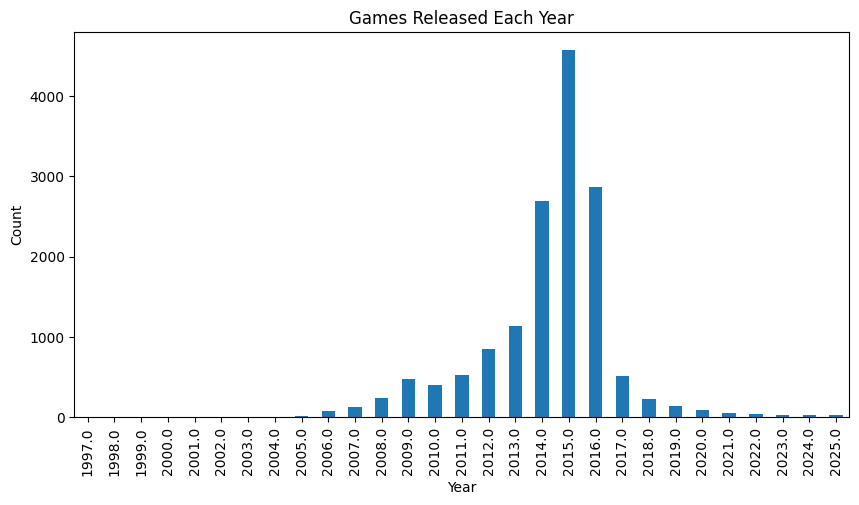

In [ ]:
apps["release_date"] = pd.to_datetime(apps["release_date"], errors="coerce")

plt.figure(figsize=(10,5))
apps["release_date"].dt.year.value_counts().sort_index().plot(kind="bar")
plt.title("Games Released Each Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


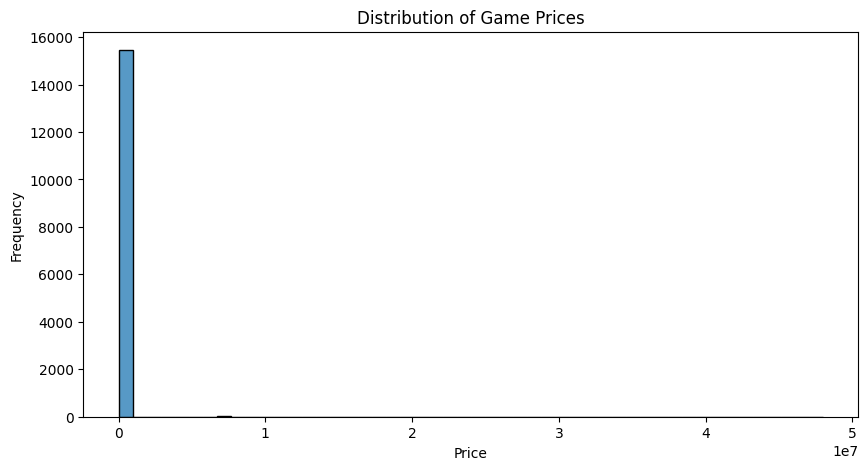

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(apps["mat_final_price"].fillna(0), bins=50)
plt.title("Distribution of Game Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


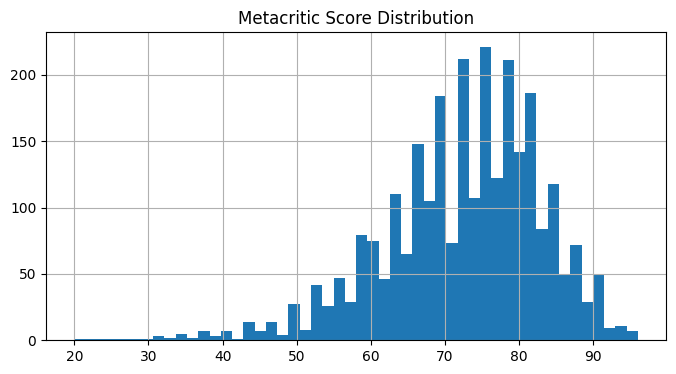

In [ ]:
apps["metacritic_score"].describe()
apps["metacritic_score"].hist(bins=50, figsize=(8,4))
plt.title("Metacritic Score Distribution")
plt.show()


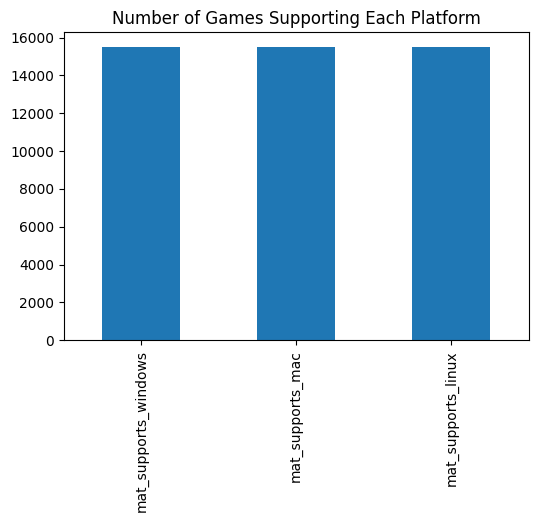

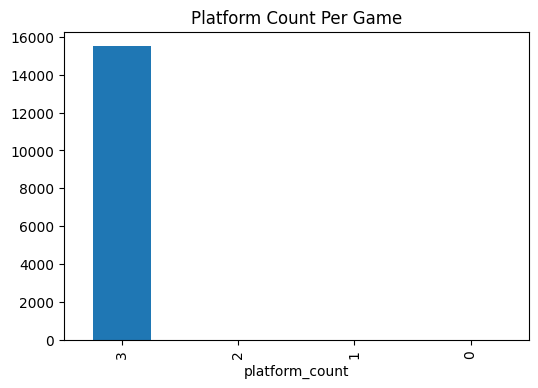

In [ ]:
platform_cols = ["mat_supports_windows", "mat_supports_mac", "mat_supports_linux"]

apps[platform_cols].sum().plot(kind="bar", figsize=(6,4))
plt.title("Number of Games Supporting Each Platform")
plt.show()

# total platforms supported
apps["platform_count"] = apps[platform_cols].sum(axis=1)

plt.figure(figsize=(6,4))
apps["platform_count"].value_counts().plot(kind="bar")
plt.title("Platform Count Per Game")
plt.show()


In [ ]:
redundant_candidates = [
    "background",
    "header_image",
    "short_description",
    "supported_languages",
    "created_at",
    "updated_at"
]

apps[redundant_candidates].head()


,background,header_image,short_description,supported_languages,created_at,updated_at
0,https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,https://store.akamai.steamstatic.com/images/st...,https://shared.akamai.steamstatic.com/store_it...,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


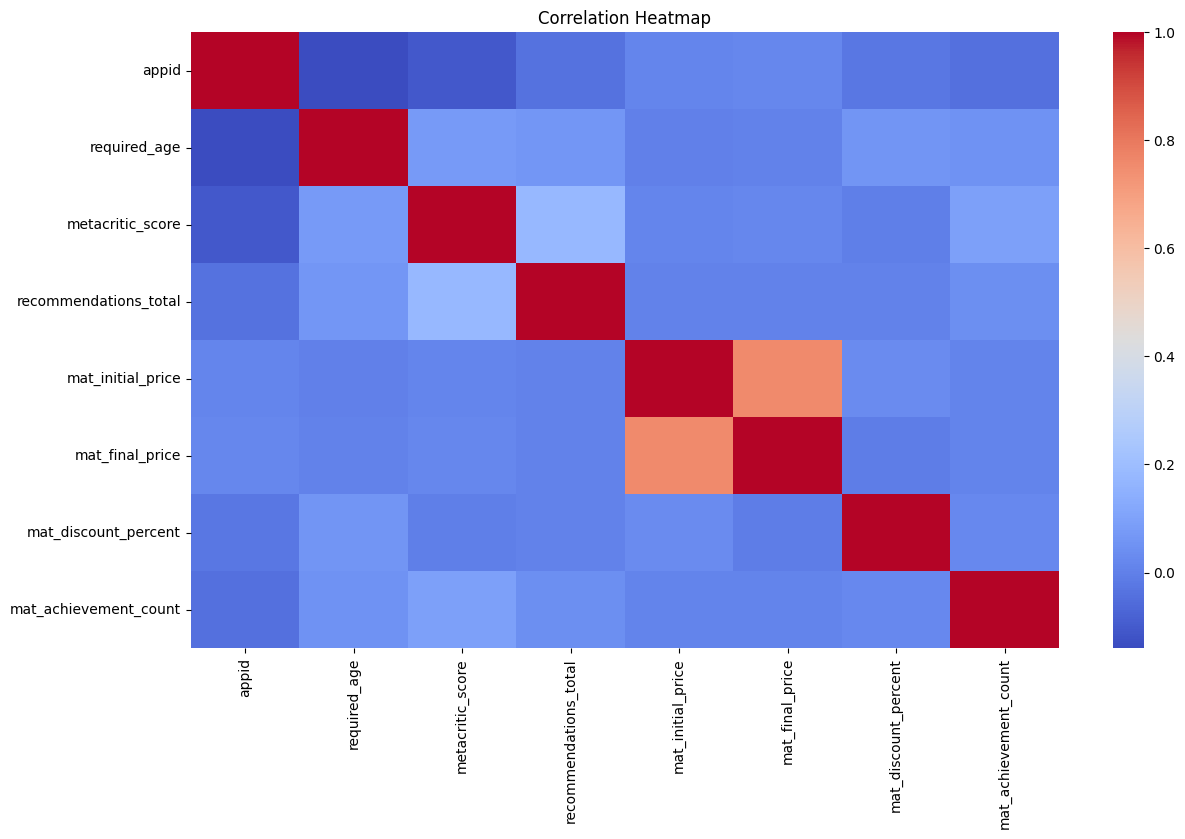

In [ ]:
plt.figure(figsize=(14,8))
sns.heatmap(apps.select_dtypes(include=np.number).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
drop_cols = []

# Drop columns with >70% missing
for col in apps.columns:
    if apps[col].isna().mean() > 0.70:
        drop_cols.append(col)

# Drop extremely high-cardinality string columns
text_cols = ["short_description", "header_image", "background", "supported_languages"]
drop_cols.extend(text_cols)

# Drop metadata
meta_cols = ["created_at", "updated_at"]
drop_cols.extend(meta_cols)

set(drop_cols)


{'background',
 'created_at',
 'header_image',
 'metacritic_score',
 'short_description',
 'supported_languages',
 'updated_at'}

In [ ]:
apps_cleaned = apps.drop(columns=list(set(drop_cols)), errors="ignore")
apps_cleaned.to_csv("applications_cleaned.csv", index=False)

print("Cleaned applications.csv saved.")
apps_cleaned.head()


Cleaned applications.csv saved.


,appid,name,type,is_free,release_date,required_age,recommendations_total,mat_supports_windows,mat_supports_mac,mat_supports_linux,mat_initial_price,mat_final_price,mat_discount_percent,mat_currency,mat_achievement_count,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,platform_count
0,10,Counter-Strike,game,False,2000-11-01,0.00,161854.00,True,True,True,999.00,999.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
1,20,Team Fortress Classic,game,False,1999-04-01,0.00,6633.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
2,30,Day of Defeat,game,False,2003-05-01,0.00,4308.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,40,Deathmatch Classic,game,False,2001-06-01,0.00,2338.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0.00,22793.00,True,True,True,499.00,499.00,0.00,USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
